🚀 Initializing Full Feature Engineering Pipeline for Notebook...
⛏️ Mining Intelligence (Synergy, Counters, Meta)...
🧠 Applying Engineered Features...
⚔️ Entering the Model Arena: Initializing 8 distinct architectures...
🧪 Training Models and Calculating Metrics (This may take a few minutes)...

   -> Training Logistic Regression...
   -> Training Naive Bayes...
   -> Training K-Nearest Neighbors...
   -> Training Random Forest...
   -> Training Gradient Boosting...
   -> Training XGBoost...
   -> Training Deep Learning (ANN)...
   -> Training Stacking Ensemble...

🏆 Final Detailed Evaluation Metrics (Ranked by AUC):


,TN (Correct Red),FP (Wrong Blue),FN (Wrong Red),TP (Correct Blue),Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC
Model,,,,,,,,,
Logistic Regression,3515,1716,1700,3367,66.83,66.24,66.45,66.34,0.73
Stacking Ensemble,3509,1722,1713,3354,66.64,66.08,66.19,66.13,0.73
XGBoost,3505,1726,1720,3347,66.54,65.98,66.05,66.02,0.72
Gradient Boosting,3493,1738,1697,3370,66.64,65.97,66.51,66.24,0.72
Random Forest,3489,1742,1742,3325,66.17,65.62,65.62,65.62,0.72
Naive Bayes,3302,1929,1840,3227,63.40,62.59,63.69,63.13,0.68
Deep Learning (ANN),3576,1655,2621,2446,58.48,59.64,48.27,53.36,0.63
K-Nearest Neighbors,3113,2118,2102,2965,59.02,58.33,58.52,58.42,0.63


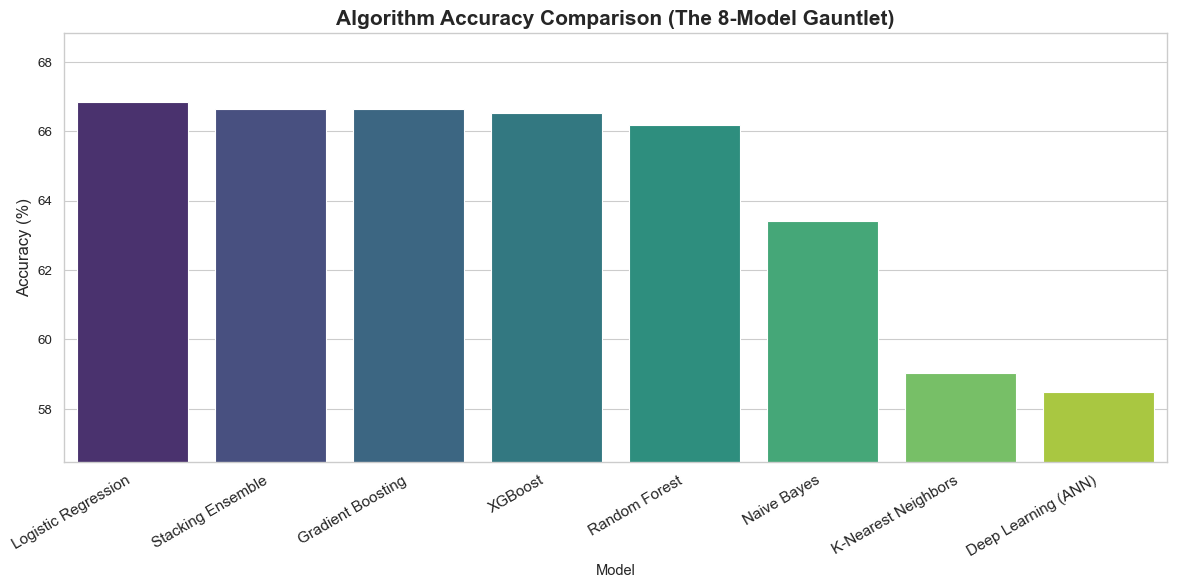

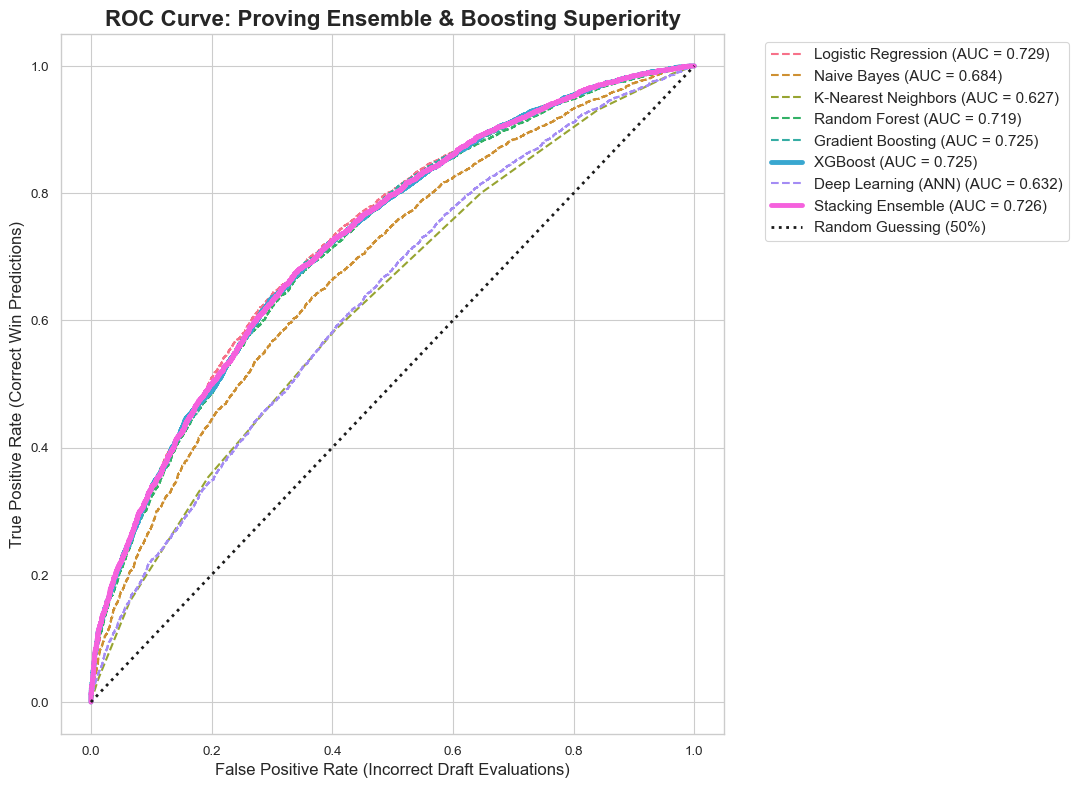

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
import json
import itertools
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix

# The 8 Model Architectures
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier

# Hide deprecation warnings for a clean notebook output
warnings.filterwarnings('ignore') 

print("🚀 Initializing Full Feature Engineering Pipeline for Notebook...")

# ==========================================
# 1. HELPER FUNCTIONS & DATA LOADING
# ==========================================
def get_role_counts(ids, id_to_tags):
    roles = ['fighter', 'mage', 'marksman', 'assassin', 'support', 'tank']
    counts = {role: 0 for role in roles}
    for cid in ids:
        tags = id_to_tags.get(str(cid), [])
        for tag in tags:
            tag_l = tag.lower()
            if tag_l in counts: counts[tag_l] += 1
    return counts

# Load Resources
df = pd.read_csv('../data/games.csv')
with open('../data/champion_info_2.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)

data = raw['data'] if 'data' in raw else raw
id_to_tags = {}
if isinstance(data, dict):
    for k, v in data.items():
        if 'id' in v:
            id_to_tags[str(v['id'])] = v.get('tags', [])
else:
    for c in data:
        id_to_tags[str(c['id'])] = c.get('tags', [])

# Dynamic Column Detection (Safety check for leaky columns)
cols = df.columns.tolist()
t1_cols = [c for c in cols if ('t1' in c.lower() or 'team1' in c.lower()) and 'id' in c.lower()][:5]
t2_cols = [c for c in cols if ('t2' in c.lower() or 'team2' in c.lower()) and 'id' in c.lower()][:5]

if not t1_cols: 
     t1_cols = [c for c in cols if ('t1' in c.lower() or 'team1' in c.lower()) and 'win' not in c.lower()][:5]
     t2_cols = [c for c in cols if ('t2' in c.lower() or 'team2' in c.lower()) and 'win' not in c.lower()][:5]

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
print("⛏️ Mining Intelligence (Synergy, Counters, Meta)...")
champ_stats, synergy_map, matchup_map = {}, {}, {}
total_games = len(df)

for _, row in df.iterrows():
    winner = row['winner'] 
    t1 = sorted([str(row[c]) for c in t1_cols])
    t2 = sorted([str(row[c]) for c in t2_cols])
    
    winning_team, losing_team = (t1, t2) if winner == 1 else (t2, t1)

    for team, is_win in [(t1, winner==1), (t2, winner==2)]:
        for cid in team:
            if cid not in champ_stats: champ_stats[cid] = {'wins':0, 'games':0}
            champ_stats[cid]['games'] += 1
            if is_win: champ_stats[cid]['wins'] += 1
        
        for c1, c2 in itertools.combinations(team, 2):
            pair = tuple(sorted((c1, c2)))
            if pair not in synergy_map: synergy_map[pair] = {'wins':0, 'games':0}
            synergy_map[pair]['games'] += 1
            if is_win: synergy_map[pair]['wins'] += 1
    
    for w_id in winning_team:
        for l_id in losing_team:
            key, rev_key = (w_id, l_id), (l_id, w_id)
            if key not in matchup_map: matchup_map[key] = {'wins':0, 'games':0}
            matchup_map[key]['games'] += 1
            matchup_map[key]['wins'] += 1
            if rev_key not in matchup_map: matchup_map[rev_key] = {'wins':0, 'games':0}
            matchup_map[rev_key]['games'] += 1

def get_rate(record):
    return 0.5 if not record else (record['wins'] + 1) / (record['games'] + 2)

meta_scores = {cid: (get_rate(stats) * 0.7) + ((stats['games'] / total_games) * 0.3) for cid, stats in champ_stats.items()}

print("🧠 Applying Engineered Features...")
X_data, y_data = [], []

for _, row in df.iterrows():
    t1 = sorted([str(row[c]) for c in t1_cols])
    t2 = sorted([str(row[c]) for c in t2_cols])
    feats = {}
    
    t1_roles = get_role_counts(t1, id_to_tags)
    t2_roles = get_role_counts(t2, id_to_tags)
    for k, v in t1_roles.items(): feats[f"t1_{k}"] = v
    for k, v in t2_roles.items(): feats[f"t2_{k}"] = v
    
    feats['t1_ap_ad_ratio'] = (t1_roles.get('mage', 0) + t1_roles.get('support', 0)) / (t1_roles.get('marksman', 0) + t1_roles.get('fighter', 0) + t1_roles.get('assassin', 0) + 1)
    feats['t2_ap_ad_ratio'] = (t2_roles.get('mage', 0) + t2_roles.get('support', 0)) / (t2_roles.get('marksman', 0) + t2_roles.get('fighter', 0) + t2_roles.get('assassin', 0) + 1)
    
    feats['t1_meta'] = sum(meta_scores.get(c, 0.5) for c in t1)
    feats['t2_meta'] = sum(meta_scores.get(c, 0.5) for c in t2)
    
    feats['t1_synergy'] = sum(get_rate(synergy_map.get(tuple(sorted(pair)))) - 0.5 for pair in itertools.combinations(t1, 2) if tuple(sorted(pair)) in synergy_map)
    feats['t2_synergy'] = sum(get_rate(synergy_map.get(tuple(sorted(pair)))) - 0.5 for pair in itertools.combinations(t2, 2) if tuple(sorted(pair)) in synergy_map)
    
    feats['t1_counter'] = sum(get_rate(matchup_map.get((c1, c2))) - 0.5 for c1 in t1 for c2 in t2 if (c1, c2) in matchup_map)
    
    X_data.append(feats)
    y_data.append(1 if row['winner'] == 2 else 0)

X = pd.DataFrame(X_data)
y = pd.Series(y_data)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. SPLIT & INITIALIZE 8 MODELS
# ==========================================
print("⚔️ Entering the Model Arena: Initializing 8 distinct architectures...")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, eval_metric='logloss', random_state=42, n_jobs=-1),
    'Deep Learning (ANN)': MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', max_iter=300, random_state=42),
}

# Add the Stacking Ensemble (Using RF and XGB as the base experts)
base_estimators = [('rf', models['Random Forest']), ('xgb', models['XGBoost'])]
models['Stacking Ensemble'] = StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(), cv=5)

# ==========================================
# 4. TRAIN & EXTRACT ALL METRICS
# ==========================================
results = []
roc_data = {}

print("🧪 Training Models and Calculating Metrics (This may take a few minutes)...\n")
for name, model in models.items():
    print(f"   -> Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] 
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Standard Binary Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc(fpr, tpr)}
    
    results.append({
        'Model': name,
        'TN (Correct Red)': tn,
        'FP (Wrong Blue)': fp,
        'FN (Wrong Red)': fn,
        'TP (Correct Blue)': tp,
        'Accuracy (%)': acc * 100,
        'Precision (%)': prec * 100,
        'Recall (%)': rec * 100,
        'F1-Score (%)': f1 * 100,
        'AUC': auc(fpr, tpr)
    })

# Sort by AUC to instantly see the best performer
results_df = pd.DataFrame(results).set_index('Model').sort_values(by='AUC', ascending=False)
print("\n🏆 Final Detailed Evaluation Metrics (Ranked by AUC):")
display(results_df.round(2))

# ==========================================
# 5. VISUALIZE RESULTS
# ==========================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# --- Chart 1: Bar Chart of Accuracies ---

plt.figure(figsize=(12, 6))
# Sort for a nice visual staircase effect
sorted_acc = results_df.sort_values(by='Accuracy (%)', ascending=False)

# Added hue and legend=False to fix Seaborn FutureWarnings
sns.barplot(
    x=sorted_acc.index, 
    y=sorted_acc['Accuracy (%)'], 
    hue=sorted_acc.index,
    palette='viridis',
    legend=False
)

plt.title('Algorithm Accuracy Comparison (The 8-Model Gauntlet)', fontsize=15, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=11)
# Zoom in on the top of the bars to see minor differences
plt.ylim(min(sorted_acc['Accuracy (%)']) - 2, max(sorted_acc['Accuracy (%)']) + 2) 
plt.tight_layout()
plt.show()

# --- Chart 2: The Master ROC Curve ---

plt.figure(figsize=(11, 8))
# Dynamic color palette for 8 lines
colors = sns.color_palette("husl", 8)

for (name, data), color in zip(roc_data.items(), colors):
    # Highlight the Ensemble and XGBoost to make them stand out
    lw = 3.5 if name in ['Stacking Ensemble', 'XGBoost'] else 1.5
    ls = '-' if name in ['Stacking Ensemble', 'XGBoost'] else '--'
    
    plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['auc']:.3f})", color=color, lw=lw, linestyle=ls)

plt.plot([0, 1], [0, 1], 'k:', lw=2, label='Random Guessing (50%)')
plt.xlabel('False Positive Rate (Incorrect Draft Evaluations)', fontsize=12)
plt.ylabel('True Positive Rate (Correct Win Predictions)', fontsize=12)
plt.title('ROC Curve: Proving Ensemble & Boosting Superiority', fontsize=16, fontweight='bold')

# Put legend outside the plot so it doesn't cover the lines
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()